# W1 Project Prep

This notebook is for the first check of the data.

I will load the datasets, check missing values, look at the sales series, and prepare the data for the next step.

## Part A - Setup

In [6]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import zscore

pd.set_option("display.max_columns", 50)

DATA_DIR = Path("/home/ana/cosas_eukene/accounts/github/time_series_analysis_ona/data")
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

In [7]:
# Check files in the data folder
list(DATA_DIR.glob("*.csv"))

[PosixPath('/home/ana/cosas_eukene/accounts/github/time_series_analysis_ona/data/holidays.csv'),
 PosixPath('/home/ana/cosas_eukene/accounts/github/time_series_analysis_ona/data/timeseries.csv'),
 PosixPath('/home/ana/cosas_eukene/accounts/github/time_series_analysis_ona/data/oil.csv'),
 PosixPath('/home/ana/cosas_eukene/accounts/github/time_series_analysis_ona/data/timeseries_with_features.csv'),
 PosixPath('/home/ana/cosas_eukene/accounts/github/time_series_analysis_ona/data/stores.csv')]

## Part B - Load data

In [8]:
df_holidays = pd.read_csv(DATA_DIR / "holidays.csv", parse_dates=["date"])
df_stores = pd.read_csv(DATA_DIR / "stores.csv")
df_oil = pd.read_csv(DATA_DIR / "oil.csv", parse_dates=["date"])
df_timeseries = pd.read_csv(DATA_DIR / "timeseries.csv", parse_dates=["date"])

In [9]:
print("Holidays:")
display(df_holidays.head())

print("Stores:")
display(df_stores.head())

print("Oil:")
display(df_oil.head())

print("Time series:")
display(df_timeseries.head())

Holidays:


,date,locale,locale_name,description
0,2012-03-02,Local,Manta,Fundacion de Manta
1,2012-04-01,Regional,Cotopaxi,Provincializacion de Cotopaxi
2,2012-04-12,Local,Cuenca,Fundacion de Cuenca
3,2012-04-14,Local,Libertad,Cantonizacion de Libertad
4,2012-04-21,Local,Riobamba,Cantonizacion de Riobamba


Stores:


,store_nbr,city,region
0,1,Quito,Pichincha
1,2,Quito,Pichincha
2,3,Quito,Pichincha
3,4,Quito,Pichincha
4,5,Santo Domingo,Santo Domingo de los Tsachilas


Oil:


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


Time series:


,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0


## Part C - Basic checks

Before plotting, I check the size of each dataset, the column types, and missing values.

In [10]:
datasets = {
    "holidays": df_holidays,
    "stores": df_stores,
    "oil": df_oil,
    "timeseries": df_timeseries
}

for name, df in datasets.items():
    print(f"--- {name} ---")
    print("Shape:", df.shape)
    print(df.dtypes)
    print("Missing values:")
    print(df.isna().sum())
    print()

--- holidays ---
Shape: (350, 4)
date           datetime64[ns]
locale                 object
locale_name            object
description            object
dtype: object
Missing values:
date           0
locale         0
locale_name    0
description    0
dtype: int64

--- stores ---
Shape: (54, 3)
store_nbr     int64
city         object
region       object
dtype: object
Missing values:
store_nbr    0
city         0
region       0
dtype: int64

--- oil ---
Shape: (1218, 2)
date          datetime64[ns]
dcoilwtico           float64
dtype: object
Missing values:
date           0
dcoilwtico    43
dtype: int64

--- timeseries ---
Shape: (452, 2)
date          datetime64[ns]
unit_sales           float64
dtype: object
Missing values:
date          0
unit_sales    0
dtype: int64



## Basic checks summary

I examined the structure and missing values of each dataset.

The holidays and stores datasets are clean and do not contain missing values. They are small and well structured, so they can be used directly.

The oil dataset contains missing values in the `dcoilwtico` column (oil price), so it will require cleaning before being used in the analysis.

The time series dataset does not contain missing values in the columns. However, this does not guarantee that all dates are present, so it is important to check for missing dates separately.

Overall, most datasets are in good condition, but some preprocessing will be needed, especially for the oil data and the time series continuity.

## Part D - Missing dates in the sales series

For time series, the dates should be continuous.  
If some dates are missing, models can have problems later.

In [32]:
df_timeseries = df_timeseries.sort_values("date")

full_dates = pd.date_range(
    start=df_timeseries["date"].min(),
    end=df_timeseries["date"].max(),
    freq="D"
)

missing_dates = full_dates.difference(df_timeseries["date"])

print("Start date:", df_timeseries["date"].min())
print("End date:", df_timeseries["date"].max())
print("Number of missing dates:", len(missing_dates))
print(missing_dates)

Start date: 2013-01-02 00:00:00
End date: 2014-03-31 00:00:00
Number of missing dates: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


The sales time series starts on 2013-01-02 and ends on 2014-03-31.

After checking the full daily date range, there are no missing dates. This means the sales series is continuous and ready for time series analysis.

In [33]:
# Fill missing dates with 0 sales
df_timeseries = (
    df_timeseries
    .set_index("date")
    .asfreq("D")
)

df_timeseries["unit_sales"] = df_timeseries["unit_sales"].fillna(0)

df_timeseries = df_timeseries.reset_index()

print("Missing values after filling dates:")
print(df_timeseries.isna().sum())

Missing values after filling dates:
date           0
unit_sales     0
day_of_week    0
day_number     0
month          0
year           0
is_weekend     0
rolling_7d     6
zscore         0
is_outlier     0
dtype: int64


I filled missing sales dates with 0.  
This keeps the series daily and avoids gaps.

In [34]:
df_timeseries[df_timeseries["rolling_7d"].isna()]

,date,unit_sales,day_of_week,day_number,month,year,is_weekend,rolling_7d,zscore,is_outlier
0,2013-01-02,582.0,Wednesday,2,1,2013,False,NaN,0.600542,False
1,2013-01-03,310.0,Thursday,3,1,2013,False,NaN,-0.969740,False
2,2013-01-04,338.0,Friday,4,1,2013,False,NaN,-0.808093,False
3,2013-01-05,654.0,Saturday,5,1,2013,True,NaN,1.016204,False
4,2013-01-06,979.0,Sunday,6,1,2013,True,NaN,2.892460,False
5,2013-01-07,541.0,Monday,0,1,2013,False,NaN,0.363845,False


In [35]:
df_timeseries.head(15)

,date,unit_sales,day_of_week,day_number,month,year,is_weekend,rolling_7d,zscore,is_outlier
0,2013-01-02,582.0,Wednesday,2,1,2013,False,NaN,0.600542,False
1,2013-01-03,310.0,Thursday,3,1,2013,False,NaN,-0.969740,False
2,2013-01-04,338.0,Friday,4,1,2013,False,NaN,-0.808093,False
3,2013-01-05,654.0,Saturday,5,1,2013,True,NaN,1.016204,False
4,2013-01-06,979.0,Sunday,6,1,2013,True,NaN,2.892460,False
5,2013-01-07,541.0,Monday,0,1,2013,False,NaN,0.363845,False
6,2013-01-08,434.0,Tuesday,1,1,2013,False,548.285714,-0.253876,False
7,2013-01-09,593.0,Wednesday,2,1,2013,False,549.857143,0.664046,False
8,2013-01-10,700.0,Thursday,3,1,2013,False,605.571429,1.281767,False
9,2013-01-11,726.0,Friday,4,1,2013,False,661.000000,1.431867,False


The rolling_7d feature has 6 missing values at the beginning of the series.

This happens because a 7-day rolling window requires previous data points, so the first days cannot be calculated.

These missing values are expected and not an issue.

## Part E - Oil data

Oil prices have missing values, so I fill them before using the column.

In [38]:
print("Missing oil values before:")
print(df_oil["dcoilwtico"].isna().sum())

df_oil = df_oil.sort_values("date")

df_oil["dcoilwtico"] = (
    df_oil["dcoilwtico"]
    .interpolate(method="linear")
    .bfill()
    .ffill()
)

print("Missing oil values after:")
print(df_oil["dcoilwtico"].isna().sum())

Missing oil values before:
0
Missing oil values after:
0


## Part E - Oil data

The oil dataset originally contained missing values in the `dcoilwtico` column, which were handled earlier using interpolation.

At this stage, no missing values remain. The interpolation step is applied again to ensure consistency, although no further changes were required.

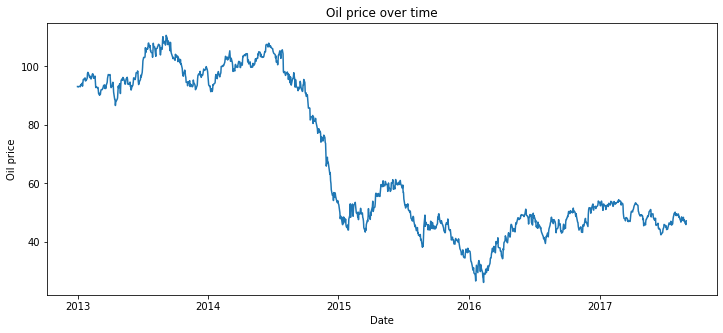

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(df_oil["date"], df_oil["dcoilwtico"])
plt.title("Oil price over time")
plt.xlabel("Date")
plt.ylabel("Oil price")
plt.show()

The oil series is now complete, with no missing values remaining.

It can be used as an external variable to explore whether changes in oil prices are related to sales.

## Part F - Holidays and stores

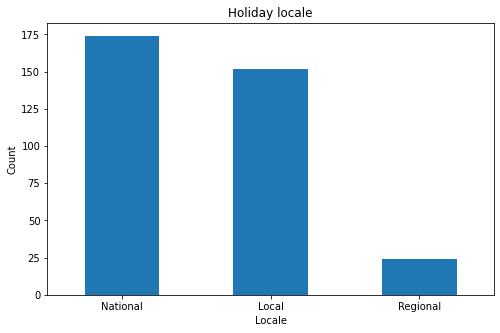

locale
National    174
Local       152
Regional     24
Name: count, dtype: int64

In [39]:
plt.figure(figsize=(8, 5))
df_holidays["locale"].value_counts().plot(kind="bar")
plt.title("Holiday locale")
plt.xlabel("Locale")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

df_holidays["locale"].value_counts()

The distribution of holidays varies by locale.

Most holidays are national (174) or local (152), while only a small number are regional (24).

This suggests that many holidays may have a broad impact on sales across the country, while others may only affect specific locations.

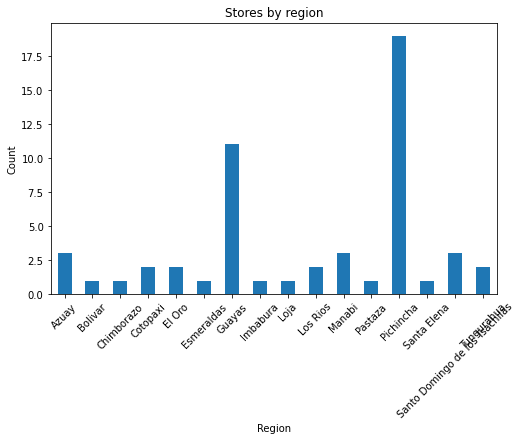

region
Pichincha                         19
Guayas                            11
Santo Domingo de los Tsachilas     3
Azuay                              3
Manabi                             3
Cotopaxi                           2
Tungurahua                         2
Los Rios                           2
El Oro                             2
Chimborazo                         1
Imbabura                           1
Bolivar                            1
Pastaza                            1
Santa Elena                        1
Loja                               1
Esmeraldas                         1
Name: count, dtype: int64

In [16]:
plt.figure(figsize=(8, 5))
df_stores["region"].value_counts().sort_index().plot(kind="bar")
plt.title("Stores by region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

df_stores["region"].value_counts()

## Data overview

The project uses four datasets: sales (main time series), oil prices, holidays, and store information.

The sales dataset is clean, continuous, and includes additional features such as rolling averages and calendar variables.

The oil dataset has been cleaned and contains no missing values. It will be used as an external variable.

The holidays dataset includes mostly national and local events, which may have different levels of impact on sales.

The stores dataset shows that stores are not evenly distributed across regions, although this information is mainly descriptive in this analysis.

## Part G - Sales over time

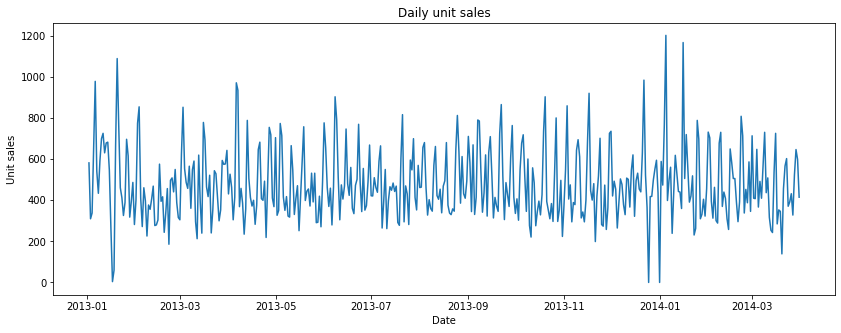

In [17]:
plt.figure(figsize=(14, 5))
plt.plot(df_timeseries["date"], df_timeseries["unit_sales"])
plt.title("Daily unit sales")
plt.xlabel("Date")
plt.ylabel("Unit sales")
plt.show()

In [40]:
df_timeseries["unit_sales"].describe()

count     454.000000
mean      477.975771
std       173.408453
min         0.000000
25%       356.500000
50%       443.500000
75%       576.750000
max      1203.000000
Name: unit_sales, dtype: float64

Daily sales show strong variability over time, ranging from 0 to 1203 units.

There are noticeable peaks and low values, indicating significant fluctuations in demand.

## Part H - Calendar patterns

In [42]:
df_timeseries["day_of_week"] = df_timeseries["date"].dt.day_name()
df_timeseries["day_number"] = df_timeseries["date"].dt.dayofweek
df_timeseries["month"] = df_timeseries["date"].dt.month
df_timeseries["year"] = df_timeseries["date"].dt.year
df_timeseries["is_weekend"] = df_timeseries["day_number"] >= 5

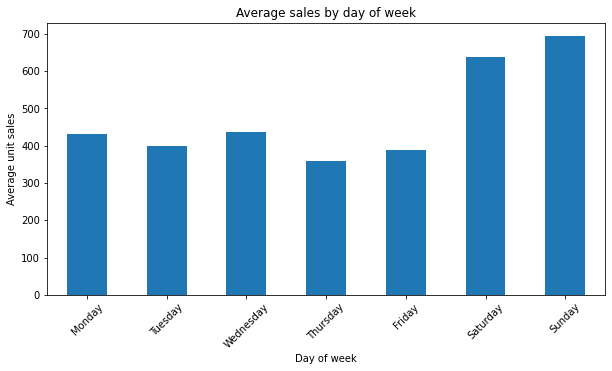

day_of_week
Monday       429.969231
Tuesday      397.718750
Wednesday    437.092308
Thursday     359.661538
Friday       389.230769
Saturday     636.830769
Sunday       694.092308
Name: unit_sales, dtype: float64

In [19]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

avg_sales_by_day = (
    df_timeseries
    .groupby("day_of_week")["unit_sales"]
    .mean()
    .reindex(day_order)
)

plt.figure(figsize=(10, 5))
avg_sales_by_day.plot(kind="bar")
plt.title("Average sales by day of week")
plt.xlabel("Day of week")
plt.ylabel("Average unit sales")
plt.xticks(rotation=45)
plt.show()

avg_sales_by_day

Average sales vary significantly across the days of the week.

Sales are much higher during the weekend, with a peak on Sunday (around 694 units) and high values on Saturday (around 637 units).

In contrast, weekday sales are lower, especially on Thursday, which shows the lowest average.

This indicates a clear weekly pattern in customer demand.

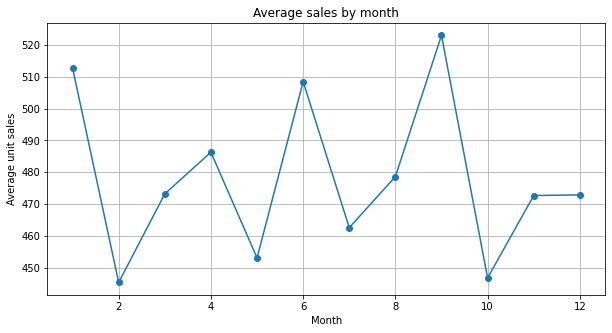

month
1     512.803279
2     445.303571
3     473.193548
4     486.300000
5     453.032258
6     508.533333
7     462.548387
8     478.612903
9     523.100000
10    446.709677
11    472.666667
12    472.870968
Name: unit_sales, dtype: float64

In [20]:
avg_sales_by_month = df_timeseries.groupby("month")["unit_sales"].mean()

plt.figure(figsize=(10, 5))
avg_sales_by_month.plot(kind="line", marker="o")
plt.title("Average sales by month")
plt.xlabel("Month")
plt.ylabel("Average unit sales")
plt.grid(True)
plt.show()

avg_sales_by_month

Sales vary slightly across months, but no clear seasonal pattern is observed.

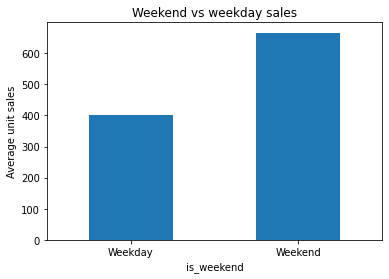

is_weekend
False    402.750000
True     665.461538
Name: unit_sales, dtype: float64

In [21]:
avg_sales_weekend = df_timeseries.groupby("is_weekend")["unit_sales"].mean()

plt.figure(figsize=(6, 4))
avg_sales_weekend.plot(kind="bar")
plt.title("Weekend vs weekday sales")
plt.ylabel("Average unit sales")
plt.xticks([0, 1], ["Weekday", "Weekend"], rotation=0)
plt.show()

avg_sales_weekend

Average sales are significantly higher on weekends (around 665 units) compared to weekdays (around 403 units).

This indicates a strong weekly pattern, where customer demand increases during weekends. This pattern will be useful for feature engineering, as it highlights the importance of including time-based variables such as day of week and weekend indicators. 

## Part I - Rolling average

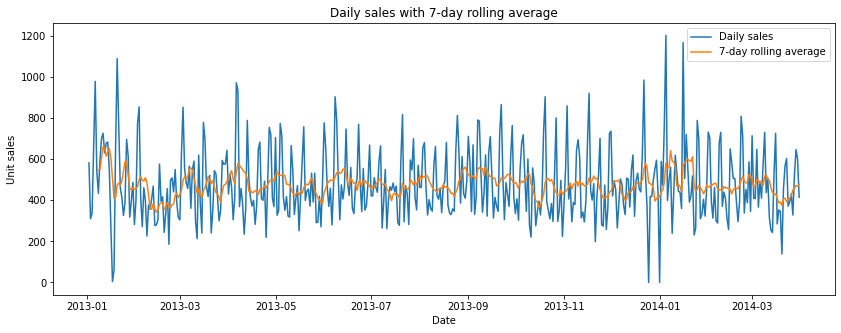

In [43]:
df_timeseries["rolling_7d"] = df_timeseries["unit_sales"].rolling(window=7).mean()

plt.figure(figsize=(14, 5))
plt.plot(df_timeseries["date"], df_timeseries["unit_sales"], label="Daily sales")
plt.plot(df_timeseries["date"], df_timeseries["rolling_7d"], label="7-day rolling average")
plt.title("Daily sales with 7-day rolling average")
plt.xlabel("Date")
plt.ylabel("Unit sales")
plt.legend()
plt.show()

The rolling average smooths daily fluctuations and makes the sales pattern easier to observe.

It helps highlight the underlying weekly pattern in the data.

## Part J - Sales and oil price

In [48]:
df_merged = df_timeseries.merge(df_oil, on="date", how="left")

print("Missing values after merge:")
print(df_merged[["unit_sales", "dcoilwtico"]].isna().sum())

df_merged[["unit_sales", "dcoilwtico"]].corr()

Missing values after merge:
unit_sales      0
dcoilwtico    130
dtype: int64


,unit_sales,dcoilwtico
unit_sales,1.000000,0.031669
dcoilwtico,0.031669,1.000000


After merging the datasets, missing values were found in the oil price column.

This occurs because some dates in the sales dataset do not have corresponding oil price data.

To ensure consistency in the analysis, these missing values need to be handled before further steps.
The correlation between unit sales and oil prices is very close to zero (0.03), suggesting that there is no strong same-day linear relationship between these variables.

In [52]:
df_merged["dcoilwtico"] = df_merged["dcoilwtico"].ffill()

In [53]:
df_merged[["date", "dcoilwtico"]].head(15)

,date,dcoilwtico
0,2013-01-02,93.14
1,2013-01-03,92.97
2,2013-01-04,93.12
3,2013-01-05,93.12
4,2013-01-06,93.12
5,2013-01-07,93.20
6,2013-01-08,93.21
7,2013-01-09,93.08
8,2013-01-10,93.81
9,2013-01-11,93.60


Some missing oil price values were identified after merging the datasets.

These missing values were filled using forward filling, which results in repeated values for consecutive dates where data was originally missing.

This ensures a continuous time series while preserving realistic price behavior.

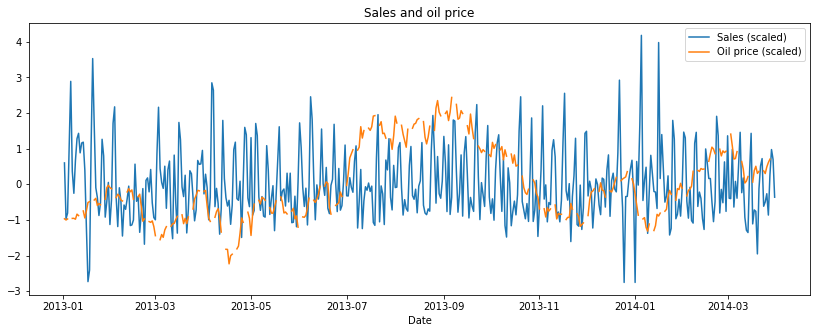

In [24]:
# Standardize both columns so they can be plotted together
df_merged["unit_sales_scaled"] = (
    df_merged["unit_sales"] - df_merged["unit_sales"].mean()
) / df_merged["unit_sales"].std()

df_merged["oil_scaled"] = (
    df_merged["dcoilwtico"] - df_merged["dcoilwtico"].mean()
) / df_merged["dcoilwtico"].std()

plt.figure(figsize=(14, 5))
plt.plot(df_merged["date"], df_merged["unit_sales_scaled"], label="Sales (scaled)")
plt.plot(df_merged["date"], df_merged["oil_scaled"], label="Oil price (scaled)")
plt.title("Sales and oil price")
plt.xlabel("Date")
plt.legend()
plt.show()

Oil price does not show a strong visual relationship with sales here.  
Still, it can be tested later as an external feature.

## Part K - Holidays

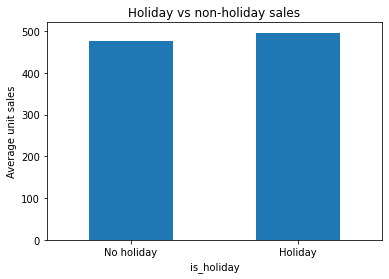

is_holiday
0    476.390123
1    496.222222
Name: unit_sales, dtype: float64

In [25]:
df_holidays_small = df_holidays[["date", "locale"]].copy()

df_merged = df_merged.merge(df_holidays_small, on="date", how="left")
df_merged["is_holiday"] = df_merged["locale"].notna().astype(int)

holiday_sales = df_merged.groupby("is_holiday")["unit_sales"].mean()

plt.figure(figsize=(6, 4))
holiday_sales.plot(kind="bar")
plt.title("Holiday vs non-holiday sales")
plt.ylabel("Average unit sales")
plt.xticks([0, 1], ["No holiday", "Holiday"], rotation=0)
plt.show()

holiday_sales

This provides a first assessment of the effect of holidays on sales.

Average sales are slightly higher on holidays (around 496) compared to non-holidays (around 476), although the difference is relatively small.

## Part L - Stationarity test

In [54]:
def run_adf(series):
    result = adfuller(series)
    p_value = result[1]

    print("ADF p-value:", p_value)

    if p_value <= 0.05:
        print("The series is likely stationary.")
    else:
        print("The series is likely not stationary.")

run_adf(df_timeseries["unit_sales"])

ADF p-value: 4.441049433078314e-06
The series is likely stationary.


The Augmented Dickey-Fuller (ADF) test was used to assess the stationarity of the sales series.

The p-value is very small (approximately 0.000004), which is below the 0.05 threshold. This suggests that the series is likely stationary.

## Part M - Decomposition

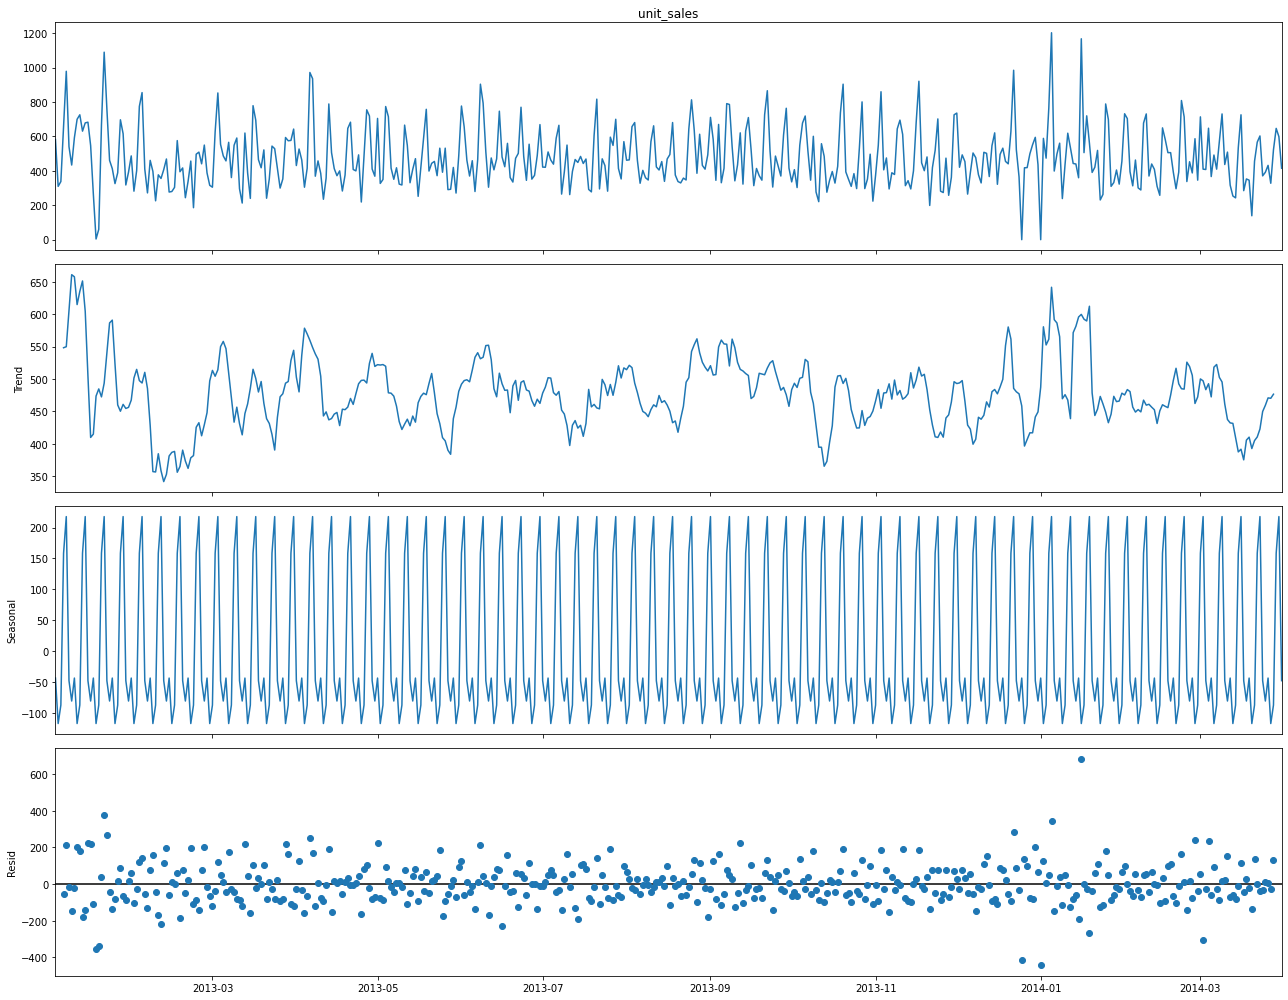

In [56]:
fig = decomp.plot()
fig.set_size_inches(18, 14)

for ax in fig.axes:
    ax.tick_params(labelsize=10)  # hace los números más grandes

plt.tight_layout()
plt.show()

The decomposition reveals a clear and consistent weekly seasonal pattern, confirming the strong differences between weekdays and weekends observed earlier.

The trend component remains relatively stable over time, with no strong long-term increase or decrease.

The residual component captures random fluctuations and a few outliers not explained by the trend or seasonality.

## Part N - Outliers

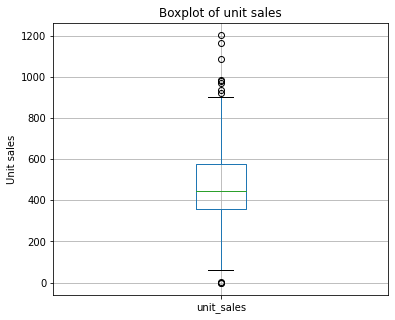

In [28]:
plt.figure(figsize=(6, 5))
df_timeseries.boxplot(column="unit_sales")
plt.title("Boxplot of unit sales")
plt.ylabel("Unit sales")
plt.show()

The boxplot shows that most unit sales values are concentrated within a moderate range around the median (around 440).

Several high-value outliers are present, indicating occasional spikes in sales. The distribution appears slightly skewed towards higher values.

In [29]:
df_timeseries["zscore"] = zscore(df_timeseries["unit_sales"])
df_timeseries["is_outlier"] = df_timeseries["zscore"].abs() > 3

outliers = df_timeseries[df_timeseries["is_outlier"]]

print("Number of outliers:", len(outliers))
display(outliers.head())

Number of outliers: 3


,date,unit_sales,day_of_week,day_number,month,year,is_weekend,rolling_7d,zscore,is_outlier
18,2013-01-20,1090.0,Sunday,6,1,2013,True,473.714286,3.533273,True
368,2014-01-05,1203.0,Sunday,6,1,2014,True,580.571429,4.185632,True
379,2014-01-16,1168.0,Thursday,3,1,2014,False,571.571429,3.983574,True


Outliers were detected using the z-score method with a threshold greater than 3.

Only a small number of outliers (3 observations) were identified, indicating occasional spikes in sales rather than widespread anomalies.

Some of these outliers occur during weekends, which is consistent with the previously observed higher sales during these days.

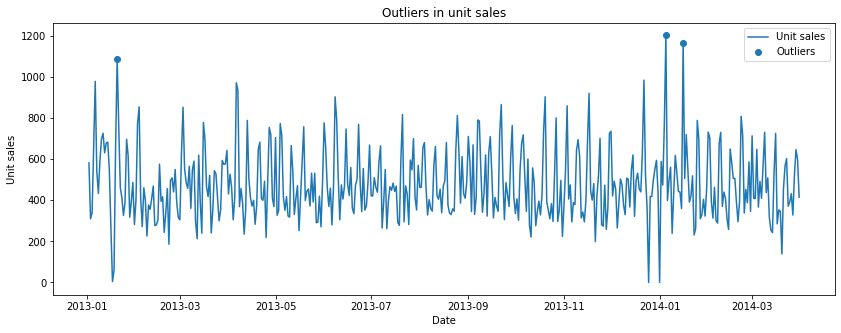

In [30]:
plt.figure(figsize=(14, 5))
plt.plot(df_timeseries["date"], df_timeseries["unit_sales"], label="Unit sales")

plt.scatter(
    outliers["date"],
    outliers["unit_sales"],
    label="Outliers"
)

plt.title("Outliers in unit sales")
plt.xlabel("Date")
plt.ylabel("Unit sales")
plt.legend()
plt.show()

Three outliers were identified in the sales series, indicating occasional spikes in demand.


## Part O - Autocorrelation

<Figure size 864x432 with 0 Axes>

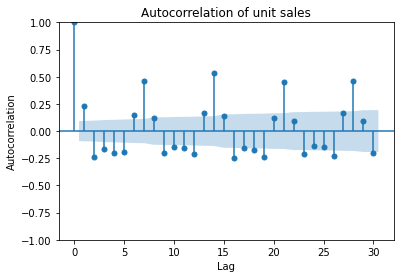

In [31]:
plt.figure(figsize=(12, 6))
plot_acf(df_timeseries["unit_sales"], lags=30)
plt.title("Autocorrelation of unit sales")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

The autocorrelation plot shows clear peaks at lag 7 and its multiples (14, 21, 28), indicating a strong weekly pattern in the sales data.

This confirms that sales tend to follow a repeating weekly cycle, consistent with previous observations of higher sales during weekends.

## Summary

Main findings from the analysis:

- The sales data was transformed into a continuous daily time series.
- Missing oil prices were handled appropriately.
- Sales are significantly higher on weekends, indicating a strong weekly pattern.
- The series contains a small number of outliers, corresponding to occasional high-demand days.
- Holidays and oil prices were explored as potential external factors, with limited impact observed.
- The ACF plot reveals a strong weekly autocorrelation, particularly at lag 7 and its multiples.

Next steps include feature engineering, such as creating lag variables, rolling averages, and incorporating calendar-based features (weekend, holidays) and external variables like oil price.